#### Feature engineering is a crucial step in the machine learning pipeline that involves transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model performance
`steps`
1. Data Collection
2. Data Cleaning
3. Data Exploration (Exploratory Data Analysis - EDA)



### 1.Data Collection
1. Collect data from our previously processed file sources for EDA and feature engineering process.
2. Understand the nature and structure of the data sources through EDA process





In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv(r'processed_data.csv')

In [6]:
print(df.head())

                  time day_of_week age_band_of_driver sex_of_driver  \
0  2025-01-31 17:02:00      Monday              18-30          Male   
1  2025-01-31 17:02:00      Monday              31-50          Male   
2  2025-01-31 17:02:00      Monday              18-30          Male   
3  2025-01-31 01:06:00      Sunday              18-30          Male   
4  2025-01-31 01:06:00      Sunday              18-30          Male   

    educational_level vehicle_driver_relation driving_experience  \
0   Above high school                Employee              1-2yr   
1  Junior high school                Employee         Above 10yr   
2  Junior high school                Employee              1-2yr   
3  Junior high school                Employee             5-10yr   
4  Junior high school                Employee              2-5yr   

       type_of_vehicle owner_of_vehicle service_year_of_vehicle  ...  \
0           Automobile            Owner              Above 10yr  ...   
1  Public (> 45 seat

### 2. Data Cleaning
1. Handle Missing Values,fill missing values using methods like mean, median, mode, or more sophisticated techniques like KNN imputation.
2. Deletion: Remove rows or columns with excessive missing values if appropriate.
3. Remove Duplicates: Identify and remove duplicate records to avoid redundancy.
we completed all this process and have processed data for EDA purpose.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15205 entries, 0 to 15204
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         15205 non-null  object 
 1   day_of_week                  15205 non-null  object 
 2   age_band_of_driver           15205 non-null  object 
 3   sex_of_driver                15205 non-null  object 
 4   educational_level            15205 non-null  object 
 5   vehicle_driver_relation      15205 non-null  object 
 6   driving_experience           15205 non-null  object 
 7   type_of_vehicle              15205 non-null  object 
 8   owner_of_vehicle             15205 non-null  object 
 9   service_year_of_vehicle      15205 non-null  object 
 10  defect_of_vehicle            15205 non-null  object 
 11  area_accident_occured        15205 non-null  object 
 12  lanes_or_medians             15205 non-null  object 
 13  road_allignment 

In [9]:
print(df.describe())

       number_of_vehicles_involved  number_of_casualties
count                  15205.00000          15205.000000
mean                       2.03295              1.443999
std                        0.62011              0.931612
min                        1.00000              1.000000
25%                        2.00000              1.000000
50%                        2.00000              1.000000
75%                        2.00000              2.000000
max                        7.00000              8.000000


In [10]:
print(df.isnull().sum())

time                           0
day_of_week                    0
age_band_of_driver             0
sex_of_driver                  0
educational_level              0
vehicle_driver_relation        0
driving_experience             0
type_of_vehicle                0
owner_of_vehicle               0
service_year_of_vehicle        0
defect_of_vehicle              0
area_accident_occured          0
lanes_or_medians               0
road_allignment                0
types_of_junction              0
road_surface_type              0
road_surface_conditions        0
light_conditions               0
weather_conditions             0
type_of_collision              0
number_of_vehicles_involved    0
number_of_casualties           0
vehicle_movement               0
casualty_class                 0
sex_of_casualty                0
age_band_of_casualty           0
casualty_severity              0
work_of_casuality              0
fitness_of_casuality           0
pedestrian_movement            0
cause_of_a

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

### 3. Data Exploration (Exploratory Data Analysis - EDA)
1. Descriptive Statistics: Calculate mean, median, mode, standard deviation, etc.
2. Data Visualization: Use plots (histograms, box plots, scatter plots) to understand data distributions and relationships.



In [14]:
print(df.describe(include=['O']))

                       time day_of_week age_band_of_driver sex_of_driver  \
count                 14736       14736              14736         14736   
unique                 1074           7                  5             3   
top     2025-01-31 15:30:00      Friday              18-30          Male   
freq                    140        2440               5488         13702   

         educational_level vehicle_driver_relation driving_experience  \
count                14736                   14736              14736   
unique                   7                       4                  7   
top     Junior high school                Employee             5-10yr   
freq                  9991                   12219               4931   

       type_of_vehicle owner_of_vehicle service_year_of_vehicle  ...  \
count            14736            14736                   14736  ...   
unique              17                4                       6  ...   
top         Automobile            Own

In [17]:
print(df['day_of_week'].value_counts())

day_of_week
Friday       2440
Thursday     2223
Wednesday    2170
Tuesday      2106
Saturday     2050
Monday       1992
Sunday       1755
Name: count, dtype: int64


In [18]:
print(df['cause_of_accident'].value_counts())

cause_of_accident
No distancing                           2740
Changing lane to the right              2170
Changing lane to the left               1720
Driving carelessly                      1678
No priority to vehicle                  1442
Moving Backward                         1364
No priority to pedestrian                853
Other                                    539
Overtaking                               511
Driving under the influence of drugs     413
Driving to the left                      342
Getting off the vehicle improperly       234
Driving at high speed                    210
Overturning                              183
Turnover                                 101
Overspeed                                 77
Overloading                               70
Drunk driving                             32
Unknown                                   29
Improper parking                          28
Name: count, dtype: int64


In [19]:
print(df.groupby('accident_severity').size())

accident_severity
Fatal injury        186
Serious Injury     2068
Slight Injury     12482
dtype: int64


In [20]:
df['number_of_casualties'].mean()

np.float64(1.458129750271444)

In [21]:
print(df['area_accident_occured'].value_counts())

area_accident_occured
Other                              4858
Office areas                       4018
Residential areas                  2495
 Church areas                      1330
 Industrial areas                   552
School areas                        504
  Recreational areas                327
 Outside rural areas                265
 Hospital areas                     144
  Market areas                       80
Rural village areas                  62
  RecreatioNAl areas                 53
Rural village areasOffice areas      25
Unknown                              22
Recreational areas                    1
Name: count, dtype: int64


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, norm
import statsmodels.api as sm

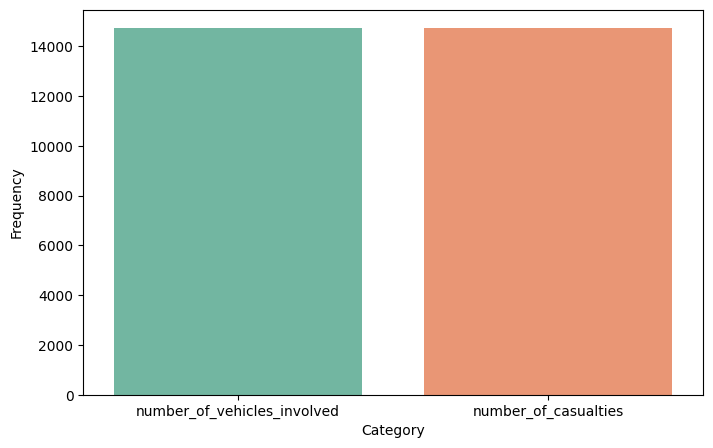

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, palette='Set2')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

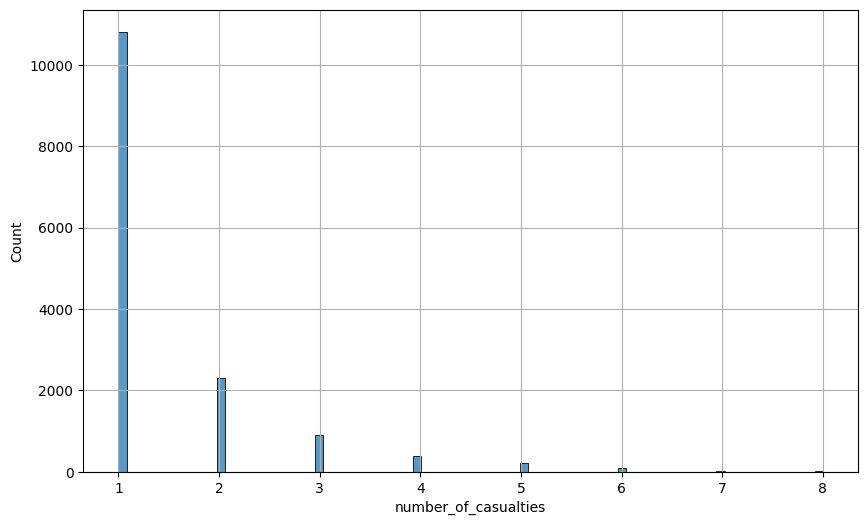

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='number_of_casualties')
plt.grid()
plt.show()

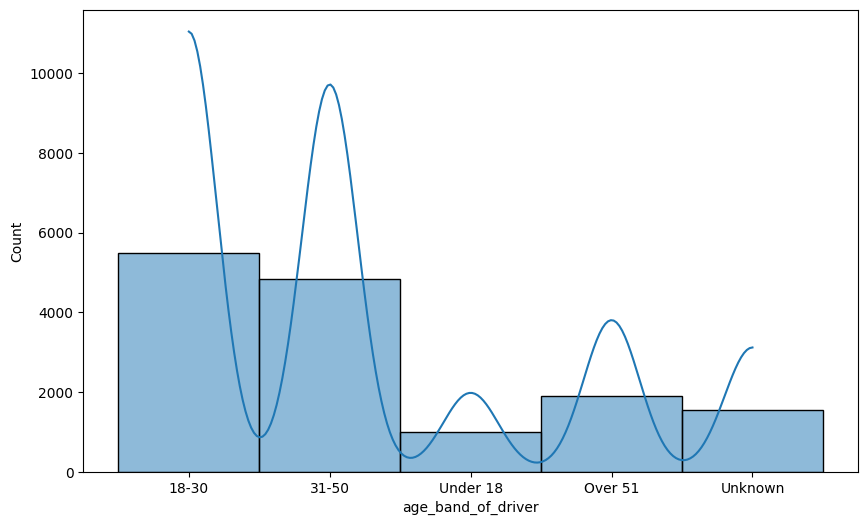

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(df['age_band_of_driver'],kde=True)
plt.show()

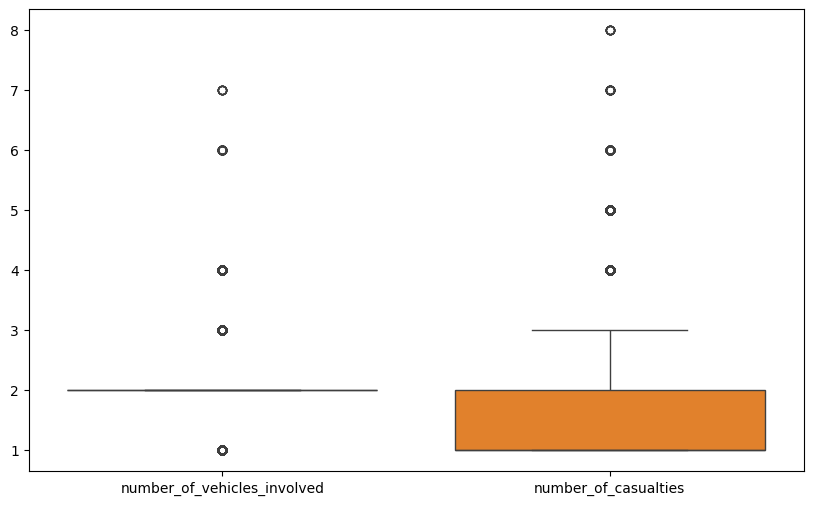

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.show()

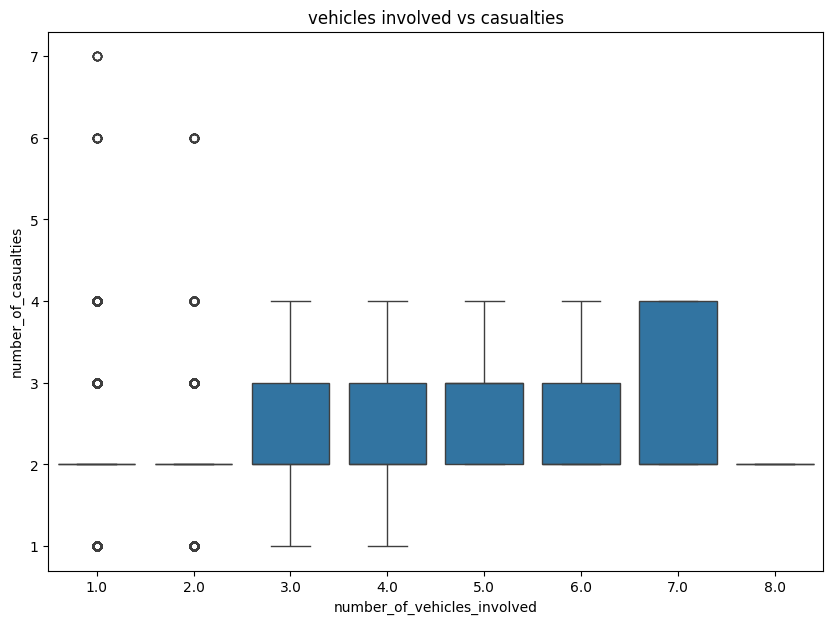

In [27]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df, y='number_of_vehicles_involved', x='number_of_casualties')
plt.xlabel('number_of_vehicles_involved')
plt.ylabel('number_of_casualties')
plt.title('vehicles involved vs casualties')
plt.show()

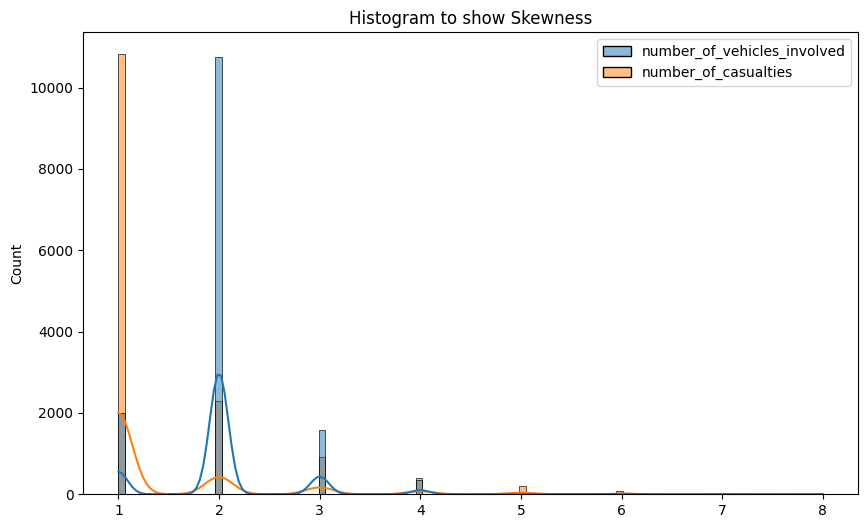

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df, kde=True)
plt.title("Histogram to show Skewness")
plt.show()

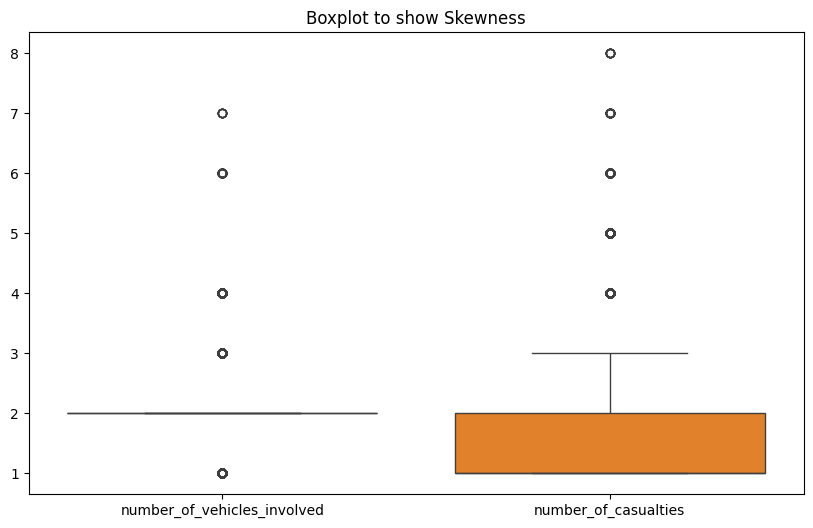

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(df)
plt.title("Boxplot to show Skewness")
plt.show()

In [ ]:
for column in df.select_dtypes(include=['object']).columns:
    try:
        df[column] = pd.to_numeric(df[column])
    except ValueError:
        print(f"Could not convert column '{column}' to numeric. It may contain non-numeric values.")

# Now calculate the kurtosis
data_kurtosis = kurtosis(df.select_dtypes(include=np.number)) # Only include numeric columns
print(f"Kurtosis: {data_kurtosis}")

Could not convert column 'time' to numeric. It may contain non-numeric values.
Could not convert column 'day_of_week' to numeric. It may contain non-numeric values.
Could not convert column 'age_band_of_driver' to numeric. It may contain non-numeric values.
Could not convert column 'sex_of_driver' to numeric. It may contain non-numeric values.
Could not convert column 'educational_level' to numeric. It may contain non-numeric values.
Could not convert column 'vehicle_driver_relation' to numeric. It may contain non-numeric values.
Could not convert column 'driving_experience' to numeric. It may contain non-numeric values.
Could not convert column 'type_of_vehicle' to numeric. It may contain non-numeric values.
Could not convert column 'owner_of_vehicle' to numeric. It may contain non-numeric values.
Could not convert column 'service_year_of_vehicle' to numeric. It may contain non-numeric values.
Could not convert column 'defect_of_vehicle' to numeric. It may contain non-numeric values.


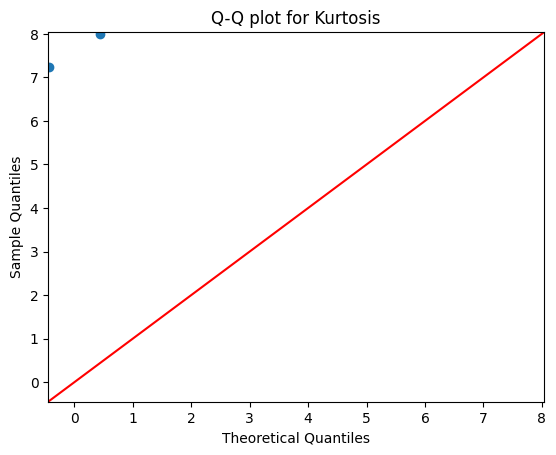

In [ ]:
sm.qqplot(data_kurtosis, line='45')
plt.title("Q-Q plot for Kurtosis")
plt.show()


In [ ]:
frequency_table = df.columns.value_counts().reset_index()
frequency_table.columns = ['Category', 'Frequency']
print(frequency_table)

                       Category  Frequency
0                          time          1
1                   day_of_week          1
2            age_band_of_driver          1
3                 sex_of_driver          1
4             educational_level          1
5       vehicle_driver_relation          1
6            driving_experience          1
7               type_of_vehicle          1
8              owner_of_vehicle          1
9       service_year_of_vehicle          1
10            defect_of_vehicle          1
11        area_accident_occured          1
12             lanes_or_medians          1
13              road_allignment          1
14            types_of_junction          1
15            road_surface_type          1
16      road_surface_conditions          1
17             light_conditions          1
18           weather_conditions          1
19            type_of_collision          1
20  number_of_vehicles_involved          1
21         number_of_casualties          1
22         

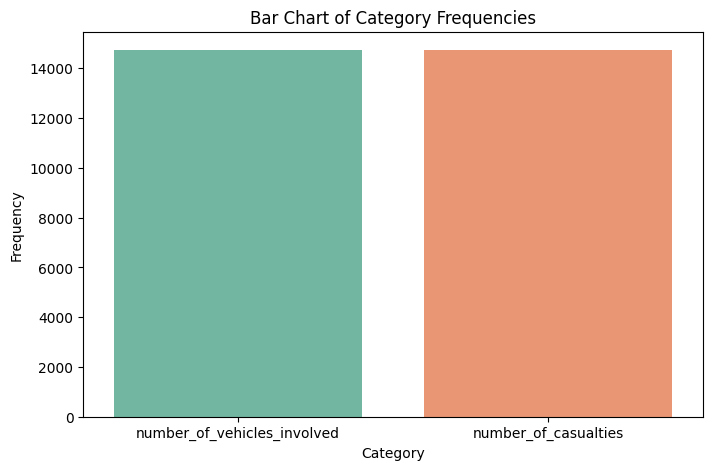

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, palette='Set2')
plt.title('Bar Chart of Category Frequencies')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

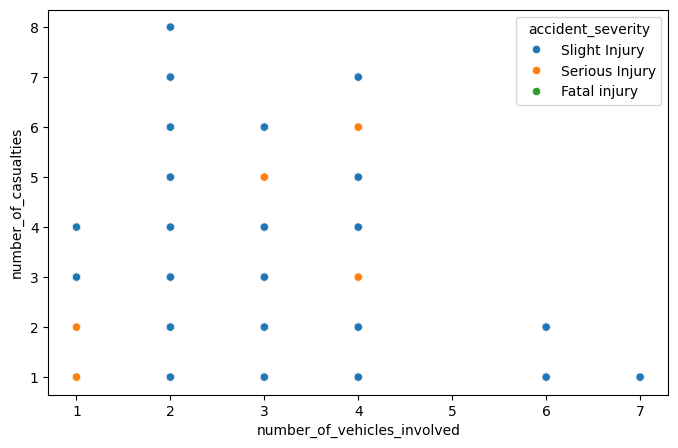

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(df,x='number_of_vehicles_involved',y='number_of_casualties', hue='accident_severity')
plt.xlabel('number_of_vehicles_involved')
plt.ylabel('number_of_casualties')
plt.show()


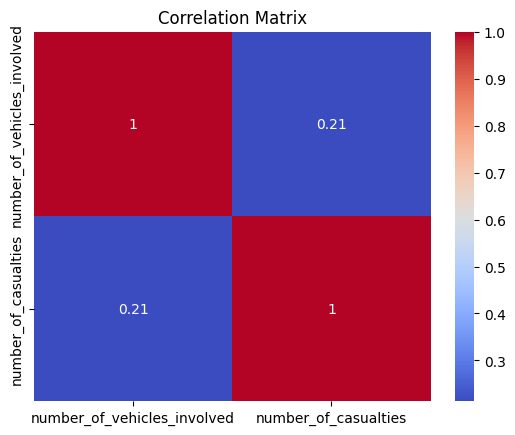

In [ ]:
correlation_matrix = df[['number_of_vehicles_involved','number_of_casualties']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

/tmp/ipykernel_7200/2740020435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='number_of_vehicles_involved', y='number_of_casualties', data=df, palette='Set2')


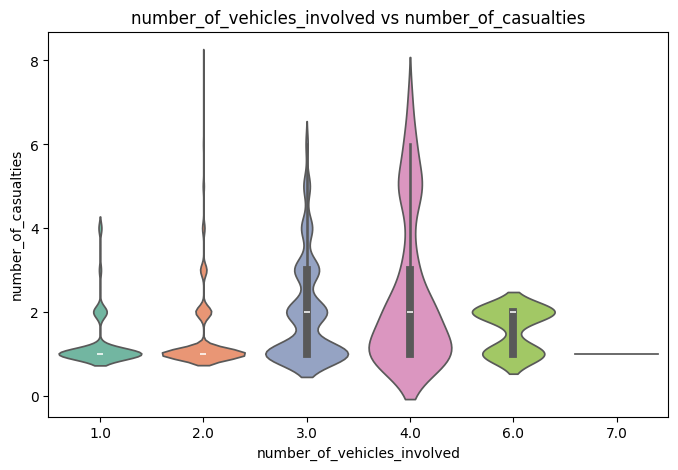

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='number_of_vehicles_involved', y='number_of_casualties', data=df, palette='Set2')
plt.title('number_of_vehicles_involved vs number_of_casualties')
plt.xlabel('number_of_vehicles_involved')
plt.ylabel('number_of_casualties')
plt.show()

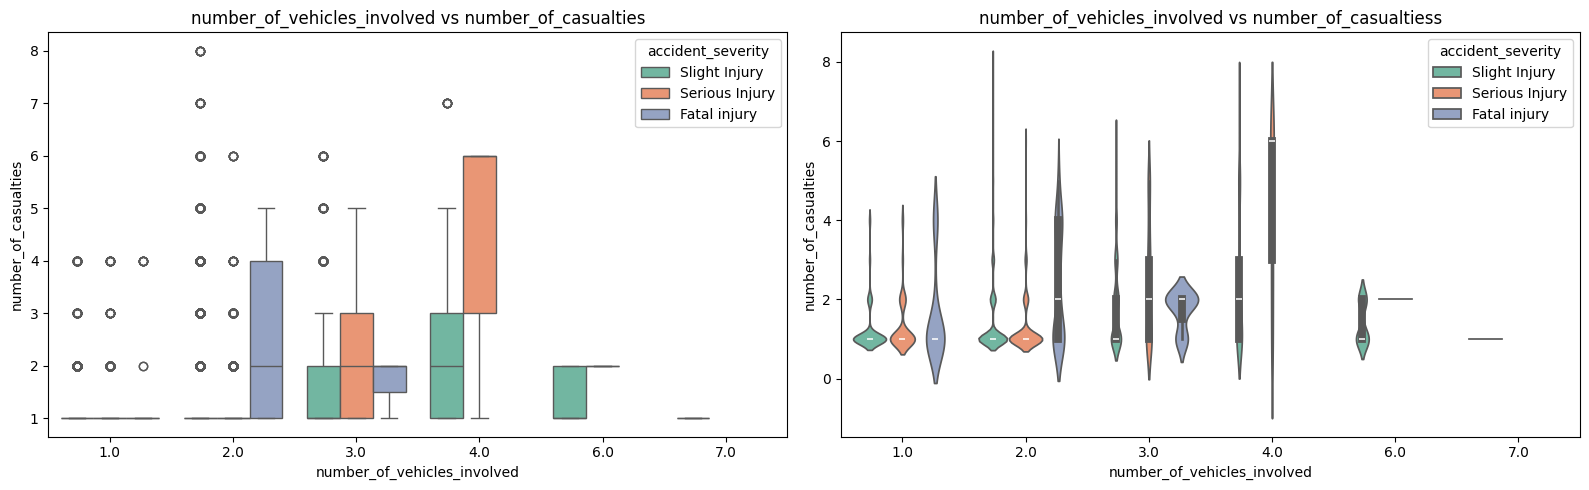

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Box Plot on the left
sns.boxplot(x='number_of_vehicles_involved', y='number_of_casualties', data=df, palette='Set2',hue = 'accident_severity', ax=axes[0])
axes[0].set_title('number_of_vehicles_involved vs number_of_casualties')
axes[0].set_xlabel('number_of_vehicles_involved')
axes[0].set_ylabel('number_of_casualties')

# Violin Plot on the right
sns.violinplot(x='number_of_vehicles_involved', y='number_of_casualties', data=df,hue='accident_severity', palette='Set2', ax=axes[1])
axes[1].set_title('number_of_vehicles_involved vs number_of_casualtiess')
axes[1].set_xlabel('number_of_vehicles_involved')
axes[1].set_ylabel('number_of_casualties')

plt.tight_layout()
plt.show()


In [ ]:
cross_tab = pd.crosstab(df['number_of_vehicles_involved'], df['number_of_casualties'])
cross_tab

number_of_casualties,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
number_of_vehicles_involved,,,,,,,,
1.0,1635,266,39,56,0,0,0,0
2.0,8223,1530,610,225,101,49,14,8
3.0,774,380,232,103,60,19,0,0
4.0,160,90,28,10,46,21,8,0
6.0,18,24,0,0,0,0,0,0
7.0,7,0,0,0,0,0,0,0


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


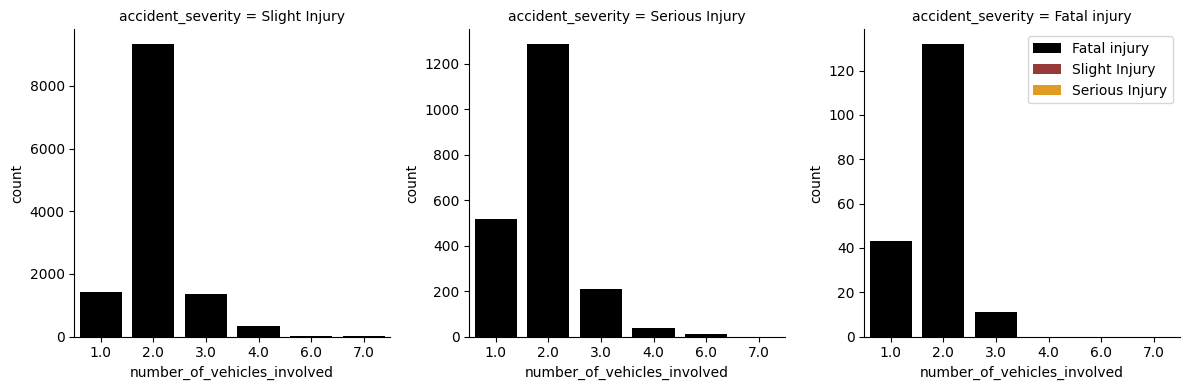

In [ ]:
grid = sns.FacetGrid(data=df, col='accident_severity', height=4, aspect=1, sharey=False)
grid.map(sns.countplot, 'number_of_vehicles_involved', data=df, hue='accident_severity', palette=['black', 'brown', 'orange']) # Added data=df
plt.legend()
plt.show()


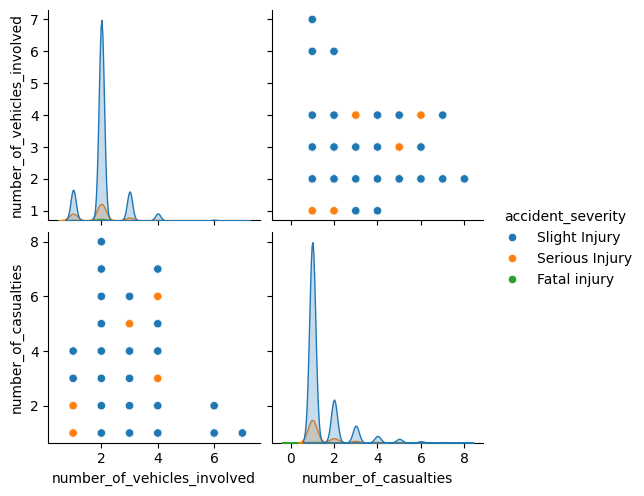

In [ ]:
sns.pairplot(df, hue='accident_severity')
plt.show()

Class 0: 12482
Class 1: 2068
Proportion: 6.04 : 1


/tmp/ipykernel_7200/3460784707.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Class 0:', target_count[0])
/tmp/ipykernel_7200/3460784707.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Class 1:', target_count[1])
/tmp/ipykernel_7200/3460784707.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')


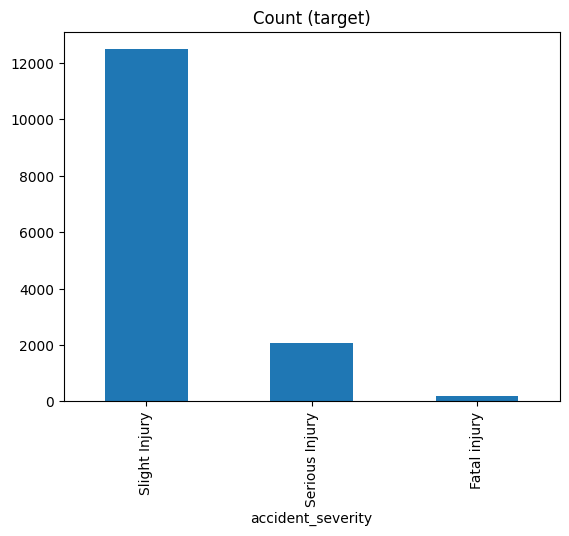

In [ ]:
target_count = df['accident_severity'].value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)')
plt.show();

In [ ]:
# dropping unnecessary columns
lists=['vehicle_driver_relation', 'work_of_casuality', 'fitness_of_casuality','day_of_week','casualty_severity','time','sex_of_driver','educational_level','defect_of_vehicle','owner_of_vehicle','service_year_of_vehicle', 'road_surface_type','sex_of_casualty']
df.drop(columns = lists, inplace=True)

In [30]:
print(df['weather_conditions'].value_counts())

weather_conditions
Normal               12025
Raining               1612
Other                  363
Unknown                347
Cloudy                 142
Windy                  118
Snow                    74
Raining and Windy       45
Fog or mist             10
Name: count, dtype: int64


In [28]:
print(df.head())

                  time day_of_week age_band_of_driver sex_of_driver  \
0  2025-01-31 17:02:00      Monday              18-30          Male   
1  2025-01-31 17:02:00      Monday              31-50          Male   
2  2025-01-31 17:02:00      Monday              18-30          Male   
3  2025-01-31 01:06:00      Sunday              18-30          Male   
4  2025-01-31 01:06:00      Sunday              18-30          Male   

    educational_level vehicle_driver_relation driving_experience  \
0   Above high school                Employee              1-2yr   
1  Junior high school                Employee         Above 10yr   
2  Junior high school                Employee              1-2yr   
3  Junior high school                Employee             5-10yr   
4  Junior high school                Employee              2-5yr   

       type_of_vehicle owner_of_vehicle service_year_of_vehicle  ...  \
0           Automobile            Owner              Above 10yr  ...   
1  Public (> 45 seat